# Capstone Project — Diabetes Risk Prediction
### AI/ML Internship | Weeks 5–6 | Sprint 1: EDA, Data Cleaning & Feature Engineering

Prepared by: Syed Muhammad Ali Bokhari

**Problem Statement:** Build a supervised machine learning model that predicts whether a patient is
likely to have diabetes based on diagnostic health measurements, and surface the key risk factors
driving each prediction. Early, low-cost risk flagging like this is useful in primary-care / screening
contexts where full diagnostic testing isn't always immediately available.

**Dataset:** Pima Indians Diabetes Dataset — 768 patient records, 8 diagnostic features, binary target
(`Outcome`: 1 = diabetic, 0 = not diabetic).

**This notebook (Sprint 1) covers:**
1. Data loading & first look
2. Exploratory Data Analysis (distributions, class balance, correlations)
3. Data cleaning (handling biologically-impossible zero values)
4. Feature engineering
5. Export of the cleaned, feature-engineered dataset for Sprint 2 (modeling)


## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42


In [2]:
# Pima Indians Diabetes Dataset (UCI / Kaggle) — no header row in the source file
COLUMN_NAMES = [
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
    "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"
]

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
df = pd.read_csv(url, names=COLUMN_NAMES)

print("Shape:", df.shape)
df.head()


Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


**First-look observations:**
- 768 rows, 9 columns, no missing (`NaN`) values reported by `.info()` — but that's misleading, see below.
- All columns are numeric already, so no encoding is needed for the raw features.
- `Outcome` is our binary target: 1 = diabetic, 0 = not diabetic.


## 2. Exploratory Data Analysis

### 2.1 Target class balance

Outcome
0    500
1    268
Name: count, dtype: int64
Outcome
0    65.1
1    34.9
Name: proportion, dtype: float64


/tmp/ipykernel_188/1607689017.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Outcome", data=df, ax=ax, palette=["#4C72B0", "#DD8452"])
/tmp/ipykernel_188/1607689017.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Non-diabetic (0)", "Diabetic (1)"])


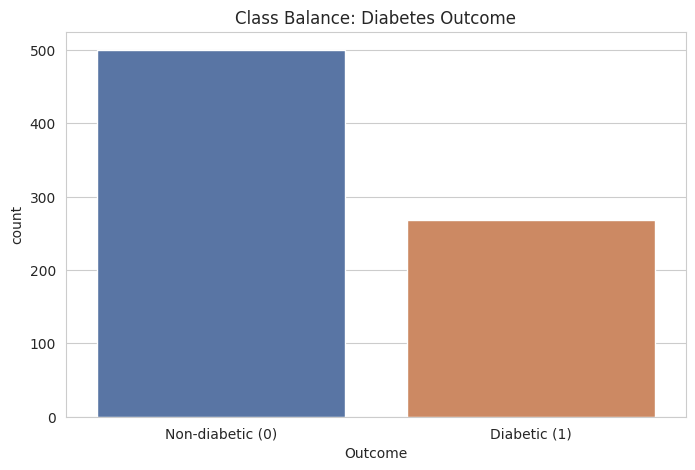

In [5]:
outcome_counts = df["Outcome"].value_counts()
outcome_pct = df["Outcome"].value_counts(normalize=True) * 100

print(outcome_counts)
print(outcome_pct.round(1))

fig, ax = plt.subplots()
sns.countplot(x="Outcome", data=df, ax=ax, palette=["#4C72B0", "#DD8452"])
ax.set_xticklabels(["Non-diabetic (0)", "Diabetic (1)"])
ax.set_title("Class Balance: Diabetes Outcome")
plt.show()


**Interpretation:** ~65% non-diabetic vs. ~35% diabetic — a mild class imbalance, not severe enough
to require SMOTE/resampling, but real enough that raw accuracy would be a misleading metric. This
confirms the decision (made in Lab 1 planning) to prioritize **recall** and **ROC-AUC** over accuracy:
a false negative here means a diabetic patient is told they're low-risk, which is the costlier error
in a screening context.

### 2.2 Feature distributions

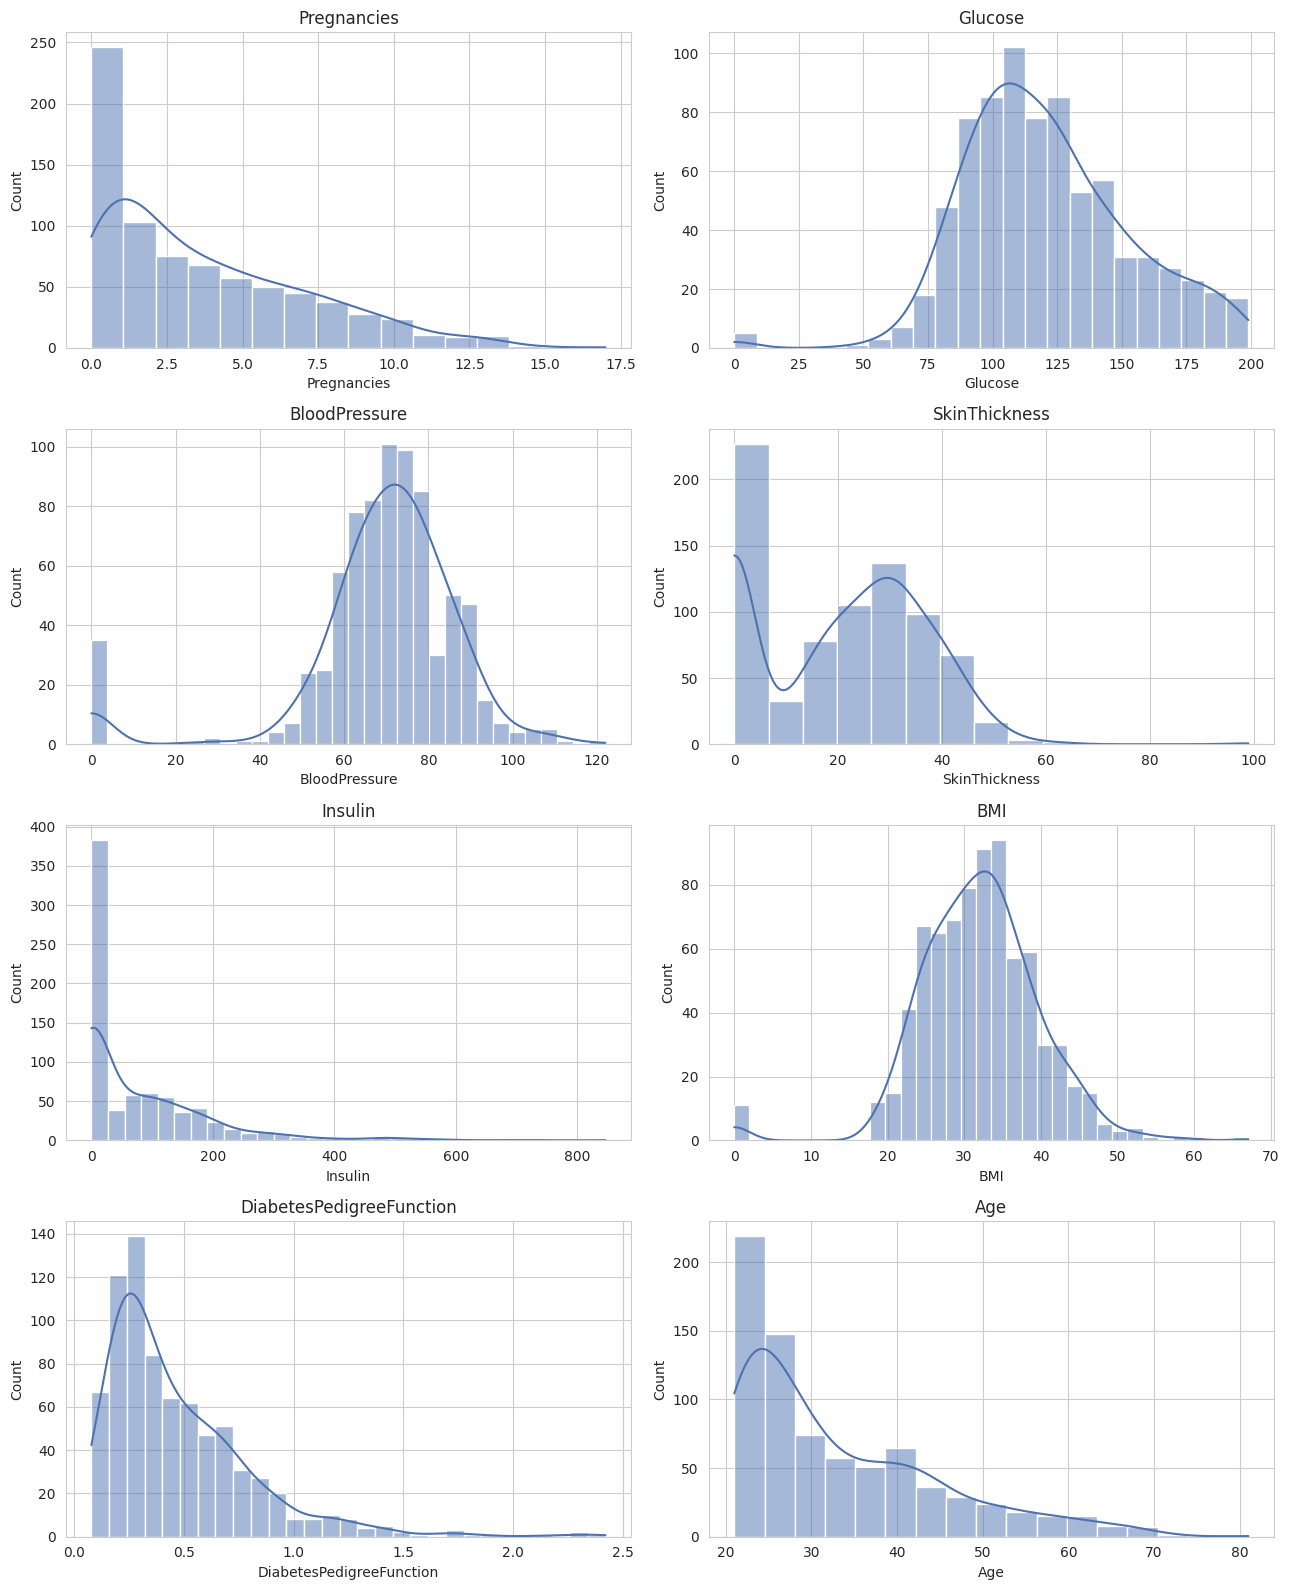

In [6]:
features = [c for c in df.columns if c != "Outcome"]

fig, axes = plt.subplots(4, 2, figsize=(13, 16))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.histplot(df[col], kde=True, ax=axes[i], color="#4C72B0")
    axes[i].set_title(col)

plt.tight_layout()
plt.show()


**Interpretation:** Several features show a suspicious spike at 0 — `Glucose`, `BloodPressure`,
`SkinThickness`, `Insulin`, and `BMI` cannot legitimately be zero in a living patient. This is a known
characteristic of this dataset: zero was used as a placeholder for "not recorded" rather than a true
missing-value marker (`NaN`), which is why `.isnull()` didn't catch it. We'll quantify and fix this in
Section 3.

### 2.3 Zero-value audit

In [7]:
zero_check_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

zero_counts = (df[zero_check_cols] == 0).sum()
zero_pct = ((df[zero_check_cols] == 0).sum() / len(df) * 100).round(1)

zero_audit = pd.DataFrame({"zero_count": zero_counts, "pct_of_rows": zero_pct})
zero_audit


,zero_count,pct_of_rows
Glucose,5,0.7
BloodPressure,35,4.6
SkinThickness,227,29.6
Insulin,374,48.7
BMI,11,1.4


**Interpretation:** `Insulin` (48.7%) and `SkinThickness` (29.6%) have very high zero rates —
too high to simply drop those rows without losing nearly half the dataset. `BloodPressure` (4.6%),
`BMI` (1.4%), and `Glucose` (0.7%) are low enough that dropping or imputing either works. This
confirms the missing-value strategy decided in Lab 1: **impute based on data semantics**, not a
blanket drop.

### 2.4 Feature relationships with the target

/tmp/ipykernel_188/2264600793.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Outcome", y=col, data=df, ax=axes[i], palette=["#4C72B0", "#DD8452"])
/tmp/ipykernel_188/2264600793.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(["Non-diabetic", "Diabetic"])
/tmp/ipykernel_188/2264600793.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Outcome", y=col, data=df, ax=axes[i], palette=["#4C72B0", "#DD8452"])
/tmp/ipykernel_188/2264600793.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax

/tmp/ipykernel_188/2264600793.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(["Non-diabetic", "Diabetic"])
/tmp/ipykernel_188/2264600793.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Outcome", y=col, data=df, ax=axes[i], palette=["#4C72B0", "#DD8452"])
/tmp/ipykernel_188/2264600793.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(["Non-diabetic", "Diabetic"])
/tmp/ipykernel_188/2264600793.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Outcome", y=col, d

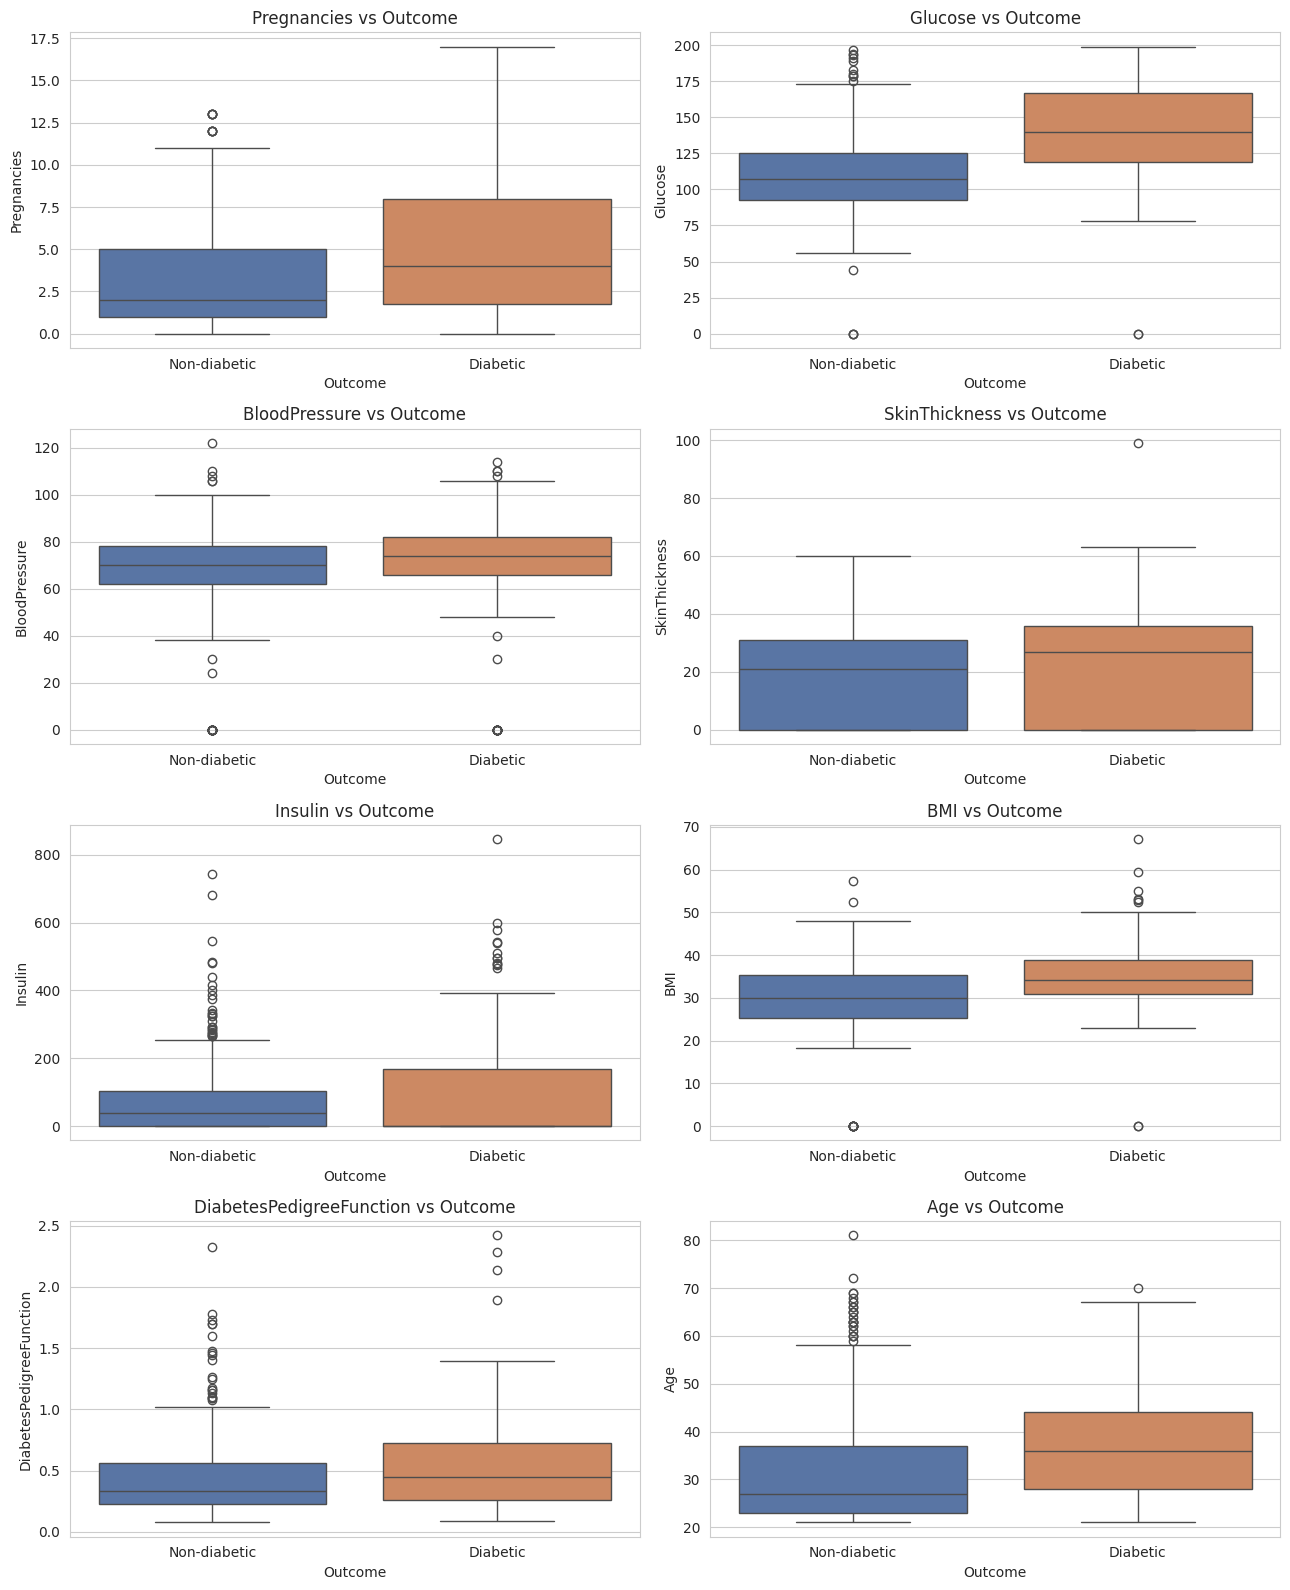

In [8]:
fig, axes = plt.subplots(4, 2, figsize=(13, 16))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(x="Outcome", y=col, data=df, ax=axes[i], palette=["#4C72B0", "#DD8452"])
    axes[i].set_xticklabels(["Non-diabetic", "Diabetic"])
    axes[i].set_title(f"{col} vs Outcome")

plt.tight_layout()
plt.show()


**Interpretation:** `Glucose` shows the clearest separation between classes — diabetic patients
skew noticeably higher, which lines up with clinical expectations (glucose is the primary diagnostic
marker for diabetes). `BMI`, `Age`, and `Pregnancies` also show visible (if less dramatic) separation.
`BloodPressure` and `SkinThickness` overlap heavily between classes and may end up being weaker
predictors — worth watching in Sprint 2's feature importance output.

### 2.5 Correlation heatmap

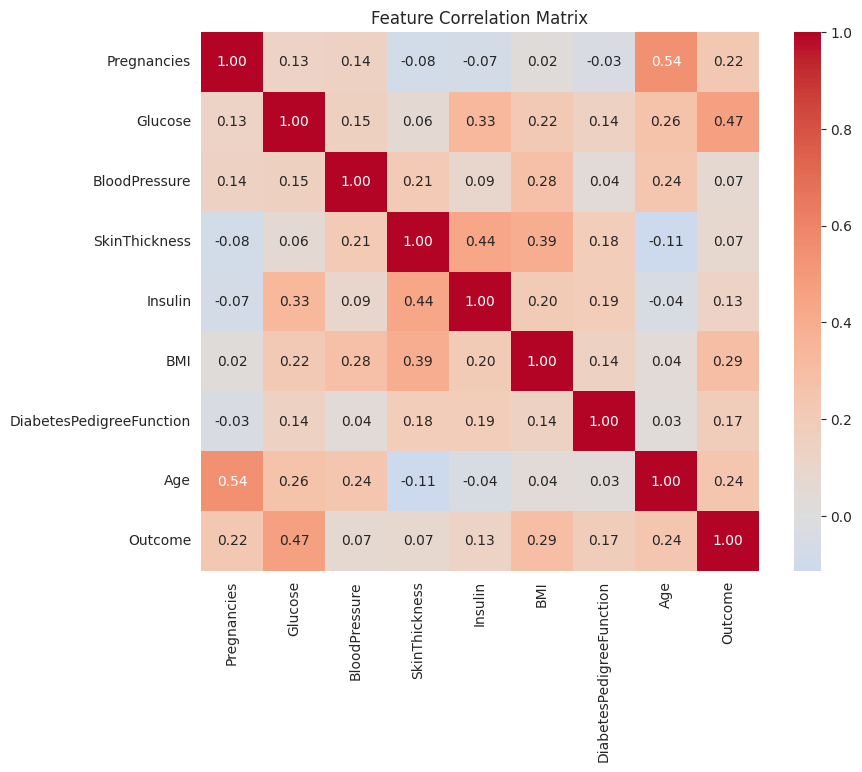

In [9]:
corr = df.corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Feature Correlation Matrix")
plt.show()


**Interpretation:** `Glucose` has the strongest correlation with `Outcome` (~0.47), consistent
with the boxplot above. `BMI`, `Age`, and `Pregnancies` show moderate positive correlation.
`SkinThickness` and `Insulin` are moderately correlated with each other (~0.44) and with `BMI`
(~0.39 / ~0.20), which makes sense physiologically — worth keeping in mind for multicollinearity in
Sprint 2, though tree-based models are robust to it and it isn't severe enough to drop either feature
outright.

## 3. Data Cleaning

**Strategy:** Replace the biologically-impossible zeros in `Glucose`, `BloodPressure`,
`SkinThickness`, `Insulin`, and `BMI` with `NaN` first (so they're explicit, not silent), then impute
using the **median, grouped by `Outcome`**, rather than a single global median. Diabetic and
non-diabetic patients have genuinely different typical values for these features (as shown in the
boxplots above), so a group-aware median preserves that signal instead of pulling both groups toward
one blended average — the same "missingness should reflect data semantics" principle applied in the
Airbnb EDA and the Telco churn assignment.

In [10]:
df_clean = df.copy()

cols_with_invalid_zeros = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

# Step 1: make the missingness explicit
df_clean[cols_with_invalid_zeros] = df_clean[cols_with_invalid_zeros].replace(0, np.nan)

print("Missing values after converting invalid zeros to NaN:")
df_clean[cols_with_invalid_zeros].isnull().sum()


Missing values after converting invalid zeros to NaN:


Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

In [11]:
# Step 2: impute using the median WITHIN each Outcome group
for col in cols_with_invalid_zeros:
    df_clean[col] = df_clean.groupby("Outcome")[col].transform(
        lambda s: s.fillna(s.median())
    )

print("Missing values after group-aware median imputation:")
df_clean[cols_with_invalid_zeros].isnull().sum()


Missing values after group-aware median imputation:


Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64

Any zeros remaining in the affected columns?
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


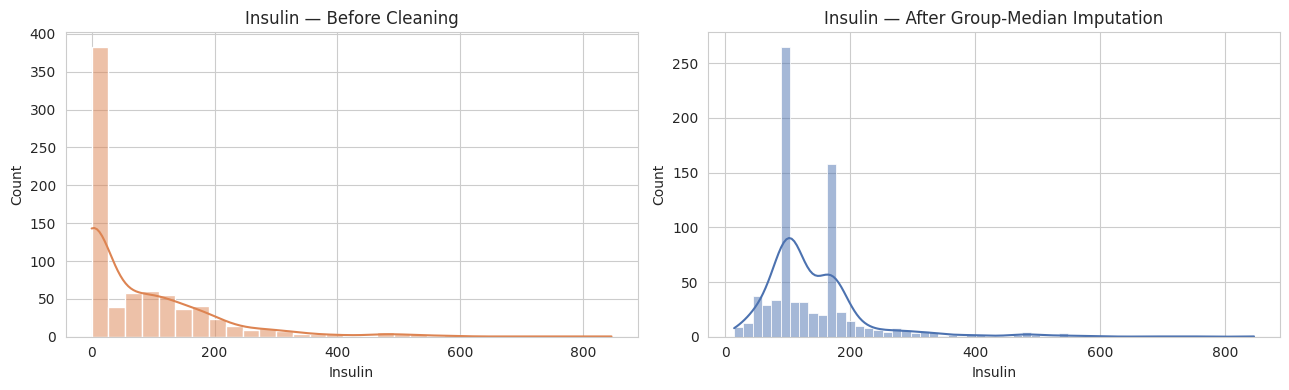

In [12]:
# Sanity check: confirm no more impossible zeros remain, and compare distributions before/after
print("Any zeros remaining in the affected columns?")
print((df_clean[cols_with_invalid_zeros] == 0).sum())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df["Insulin"], ax=axes[0], color="#DD8452", kde=True)
axes[0].set_title("Insulin — Before Cleaning")
sns.histplot(df_clean["Insulin"], ax=axes[1], color="#4C72B0", kde=True)
axes[1].set_title("Insulin — After Group-Median Imputation")
plt.tight_layout()
plt.show()


**Interpretation:** The zero-spike is gone and the distribution now looks like a plausible
physiological measurement instead of a bimodal artifact. The same fix was applied to all five affected
columns; `Insulin` is shown here since it had the most zeros and made the effect most visible.

### 3.1 Outlier check (post-cleaning)

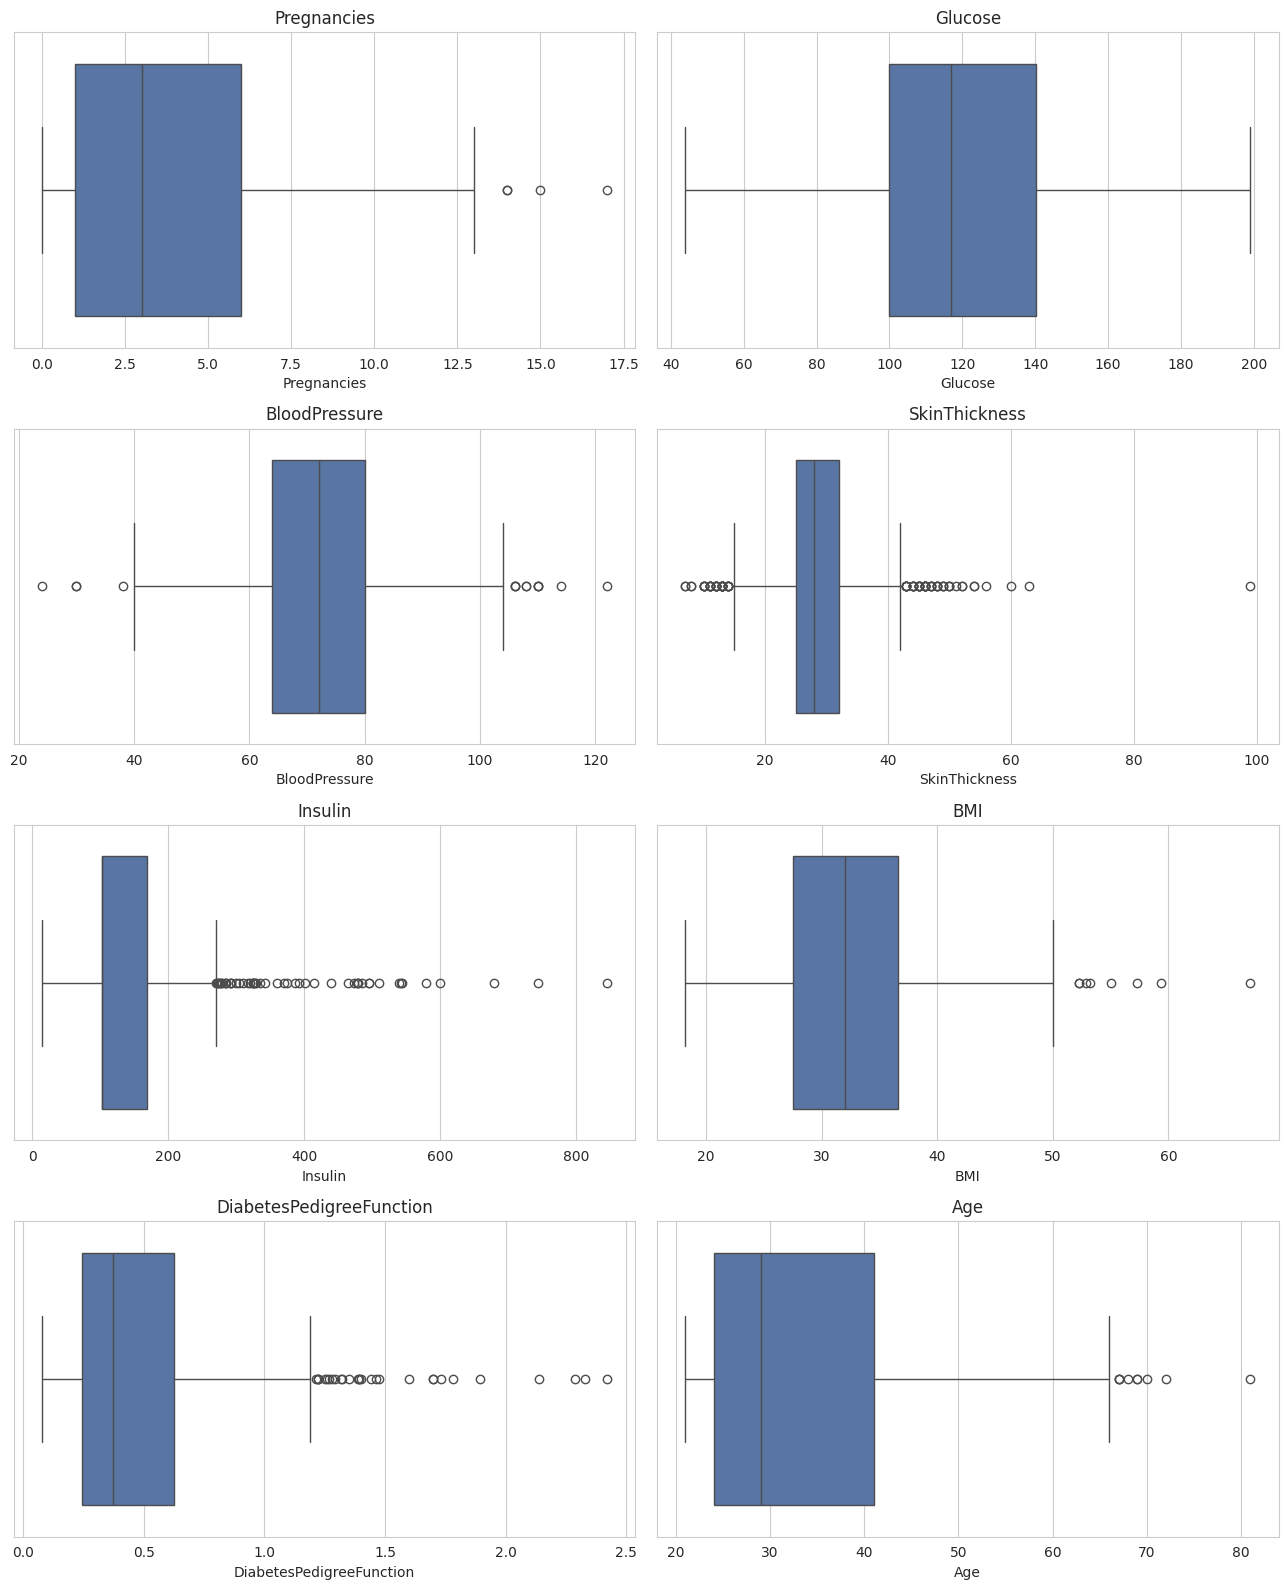

In [13]:
fig, axes = plt.subplots(4, 2, figsize=(13, 16))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(x=df_clean[col], ax=axes[i], color="#4C72B0")
    axes[i].set_title(col)

plt.tight_layout()
plt.show()


**Interpretation:** `Insulin`, `DiabetesPedigreeFunction`, and `SkinThickness` show a handful of
high-end outliers. These are being **kept, not removed** — they're plausible real patient values (e.g.
very high insulin readings do occur clinically), not data-entry errors like the zeros were. Tree-based
models (DecisionTree/RandomForest) planned for Sprint 2 are naturally robust to this kind of outlier,
and scaling in Section 4 will reduce their influence on distance-based models like KNN and Logistic
Regression.

## 4. Feature Engineering

Following the same approach used in Lab 10 (Tips dataset) and the insurance.csv assignment —
binning, interaction features, and scaling, each decided with a stated rationale rather than applied
by default.

### 4.1 Binning: BMI category

In [14]:
def bmi_category(bmi):
    if bmi < 18.5:
        return "Underweight"
    elif bmi < 25:
        return "Normal"
    elif bmi < 30:
        return "Overweight"
    else:
        return "Obese"

df_clean["BMI_Category"] = df_clean["BMI"].apply(bmi_category)
df_clean["BMI_Category"].value_counts()


BMI_Category
Obese          483
Overweight     179
Normal         102
Underweight      4
Name: count, dtype: int64

**Rationale:** Standard clinical BMI bands. A tree-based model can already split on raw `BMI`
internally, but an explicit category gives linear models (Logistic Regression) a non-linear signal
they can't otherwise capture, and makes the feature more interpretable in the final report.

### 4.2 Binning: Age group

In [15]:
def age_group(age):
    if age < 30:
        return "Young Adult"
    elif age < 45:
        return "Adult"
    elif age < 60:
        return "Middle-Aged"
    else:
        return "Senior"

df_clean["Age_Group"] = df_clean["Age"].apply(age_group)
df_clean["Age_Group"].value_counts()


Age_Group
Young Adult    396
Adult          239
Middle-Aged    101
Senior          32
Name: count, dtype: int64

**Rationale:** Diabetes risk is well known to be non-linear with age (risk rises sharply after
~45). Binning surfaces that threshold effect explicitly rather than relying on a model to infer it
from a continuous `Age` value.

### 4.3 Interaction feature: Glucose × BMI

In [16]:
df_clean["Glucose_BMI_Interaction"] = df_clean["Glucose"] * df_clean["BMI"]
df_clean[["Glucose", "BMI", "Glucose_BMI_Interaction"]].head()


,Glucose,BMI,Glucose_BMI_Interaction
0,148.0,33.6,4972.8
1,85.0,26.6,2261.0
2,183.0,23.3,4263.9
3,89.0,28.1,2500.9
4,137.0,43.1,5904.7


**Rationale:** `Glucose` and `BMI` were the two strongest individual correlates with `Outcome`
in Section 2.5. Their combined effect (high glucose *and* high BMI together) is a clinically recognized
compounding risk factor, so an explicit interaction term gives linear models access to that combined
signal directly.

### 4.4 Ratio feature: Insulin-to-Glucose ratio

In [17]:
df_clean["Insulin_Glucose_Ratio"] = df_clean["Insulin"] / df_clean["Glucose"]
df_clean[["Insulin", "Glucose", "Insulin_Glucose_Ratio"]].head()


,Insulin,Glucose,Insulin_Glucose_Ratio
0,169.5,148.0,1.145270
1,102.5,85.0,1.205882
2,169.5,183.0,0.926230
3,94.0,89.0,1.056180
4,168.0,137.0,1.226277


**Rationale:** The relationship between insulin and glucose (insulin resistance) is more
clinically meaningful than either value alone — it's part of how diabetes is diagnosed in practice.
Expressing it as a ratio gives the model a single feature that encodes that relationship directly.

### 4.5 Encoding the new categorical features

In [18]:
df_encoded = pd.get_dummies(
    df_clean,
    columns=["BMI_Category", "Age_Group"],
    drop_first=True
)

print("Shape after encoding:", df_encoded.shape)
df_encoded.head()


Shape after encoding: (768, 17)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Glucose_BMI_Interaction,Insulin_Glucose_Ratio,BMI_Category_Obese,BMI_Category_Overweight,BMI_Category_Underweight,Age_Group_Middle-Aged,Age_Group_Senior,Age_Group_Young Adult
0,6,148.0,72.0,35.0,169.5,33.6,0.627,50,1,4972.8,1.145270,True,False,False,True,False,False
1,1,85.0,66.0,29.0,102.5,26.6,0.351,31,0,2261.0,1.205882,False,True,False,False,False,False
2,8,183.0,64.0,32.0,169.5,23.3,0.672,32,1,4263.9,0.926230,False,False,False,False,False,False
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0,2500.9,1.056180,False,True,False,False,False,True
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1,5904.7,1.226277,True,False,False,False,False,False


**Rationale:** One-hot encoding (with `drop_first=True` to avoid redundancy) for these
multi-category features — consistent with the encoding convention used throughout the internship
(label encoding reserved for binary columns, one-hot for multi-category ones).

### 4.6 Correlation check including engineered features

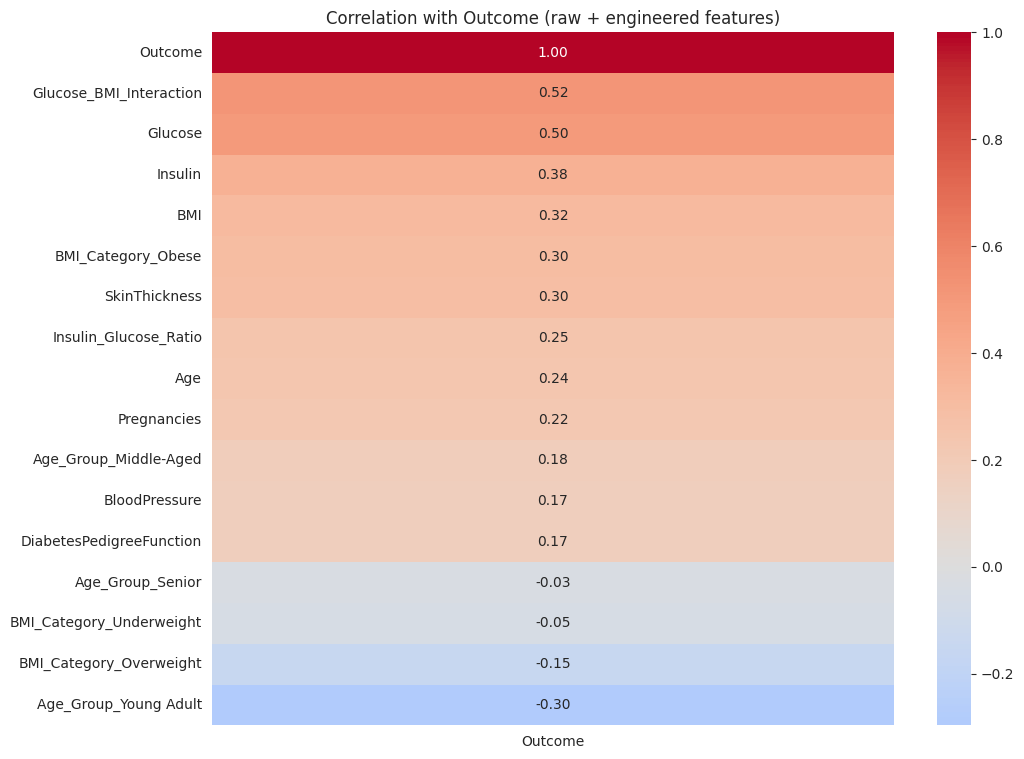

In [19]:
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(df_encoded.corr()[["Outcome"]].sort_values("Outcome", ascending=False),
            annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation with Outcome (raw + engineered features)")
plt.show()


**Interpretation:** `Glucose` remains the strongest single predictor, and
`Glucose_BMI_Interaction` also ranks highly — confirming the interaction term added real signal rather
than just noise. This will be validated properly with feature importances once models are trained in
Sprint 2, but it's a good early sign the engineered features are pulling their weight.

## 5. Export Cleaned & Feature-Engineered Dataset

In [20]:
df_encoded.to_csv("diabetes_cleaned_features.csv", index=False)
print("Saved diabetes_cleaned_features.csv with shape:", df_encoded.shape)
df_encoded.columns.tolist()


Saved diabetes_cleaned_features.csv with shape: (768, 17)


['Pregnancies',
 'Glucose',
 'BloodPressure',
 'SkinThickness',
 'Insulin',
 'BMI',
 'DiabetesPedigreeFunction',
 'Age',
 'Outcome',
 'Glucose_BMI_Interaction',
 'Insulin_Glucose_Ratio',
 'BMI_Category_Obese',
 'BMI_Category_Overweight',
 'BMI_Category_Underweight',
 'Age_Group_Middle-Aged',
 'Age_Group_Senior',
 'Age_Group_Young Adult']

## Sprint 1 Summary

- **Class balance:** ~65% / 35% (non-diabetic / diabetic) — mild imbalance, confirms recall/ROC-AUC
  as the right primary metrics (already decided in Lab 1).
- **Data quality issue found & fixed:** `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, and
  `BMI` contained biologically-impossible zeros used as an implicit "not recorded" marker. Fixed via
  group-aware (by `Outcome`) median imputation rather than a global median or row drop, preserving the
  distributional difference between diabetic and non-diabetic patients.
- **Strongest predictor so far:** `Glucose`, both alone and combined with `BMI` via the new
  interaction feature.
- **Features engineered:** `BMI_Category`, `Age_Group` (clinically-grounded bins),
  `Glucose_BMI_Interaction`, `Insulin_Glucose_Ratio` (clinically-grounded interaction/ratio terms).
- **Output:** `diabetes_cleaned_features.csv`, ready for Sprint 2 (model training & comparison —
  LogisticRegression, KNN, DecisionTree, RandomForest, and a tuned Keras model, evaluated primarily on
  recall and ROC-AUC).

**Next (Sprint 2):** train/compare the planned classifiers on this cleaned dataset, tune
hyperparameters, and select the best model against the success metrics defined in Lab 1.
